# Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks

This notebook implements a **simplified Faster R-CNN** from scratch in PyTorch, including:
- A small CNN backbone producing a shared feature map
- A **Region Proposal Network (RPN)** with anchor boxes
- **RoI Pooling** to extract fixed-size features from proposals
- A **detection head** (Fast R-CNN style) for classification and box refinement

Key ideas from the paper (Ren et al., 2015):
- The RPN shares convolutional features with the detection network → nearly cost-free proposals
- Anchors at multiple scales/aspect ratios enable multi-scale detection from a single feature map
- End-to-end training of RPN + detector replaces the slow Selective Search bottleneck

We train on a **synthetic toy detection dataset** (shapes on canvases) for speed and clarity.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

IMAGE_SIZE = 64
FEATURE_MAP_SIZE = 8  # 64 / 8 = 8x8 feature map
NUM_CLASSES = 2  # square=0, circle=1 (background is implicit class index 2)
ANCHOR_SCALES = [8, 16, 24]
ANCHOR_RATIOS = [0.5, 1.0, 2.0]
NUM_ANCHORS_PER_LOC = len(ANCHOR_SCALES) * len(ANCHOR_RATIOS)  # 9
TOTAL_ANCHORS = FEATURE_MAP_SIZE * FEATURE_MAP_SIZE * NUM_ANCHORS_PER_LOC  # 576

Device: cuda
GPU: Tesla T4


## 1. Synthetic Detection Dataset

We generate simple 64×64 grayscale images with 1–3 objects (squares or circles) at random positions. Each object has a bounding box and class label. This keeps training fast while demonstrating all pipeline components.

In [2]:
class ToyDetectionDataset(Dataset):
    """Synthetic object detection dataset: squares and circles on blank canvases."""
    def __init__(self, num_samples=500, img_size=64, max_objects=3):
        self.num_samples = num_samples
        self.img_size = img_size
        self.max_objects = max_objects
        self.data = []
        for _ in range(num_samples):
            img = np.zeros((img_size, img_size), dtype=np.float32)
            boxes = []
            labels = []
            n_objects = random.randint(1, max_objects)
            for _ in range(n_objects):
                cls = random.randint(0, 1)  # 0=square, 1=circle
                size = random.randint(10, 20)
                cx = random.randint(size//2, img_size - size//2 - 1)
                cy = random.randint(size//2, img_size - size//2 - 1)
                x1 = cx - size//2
                y1 = cy - size//2
                x2 = cx + size//2
                y2 = cy + size//2
                if cls == 0:  # square
                    img[y1:y2, x1:x2] = 1.0
                else:  # circle
                    yy, xx = np.ogrid[:img_size, :img_size]
                    mask = (xx - cx)**2 + (yy - cy)**2 <= (size//2)**2
                    img[mask] = 1.0
                boxes.append([x1, y1, x2, y2])
                labels.append(cls)
            self.data.append({
                'image': torch.from_numpy(img).unsqueeze(0),  # (1, H, W)
                'boxes': torch.tensor(boxes, dtype=torch.float32),
                'labels': torch.tensor(labels, dtype=torch.long)
            })
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    boxes = [item['boxes'] for item in batch]
    labels = [item['labels'] for item in batch]
    return images, boxes, labels

train_dataset = ToyDetectionDataset(num_samples=200)
test_dataset = ToyDetectionDataset(num_samples=30)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
print(f'Train: {len(train_dataset)} samples, Test: {len(test_dataset)} samples')
print(f'Sample image shape: {train_dataset[0]["image"].shape}')
print(f'Sample boxes: {train_dataset[0]["boxes"]}')
print(f'Sample labels: {train_dataset[0]["labels"]}')

Train: 200 samples, Test: 30 samples
Sample image shape: torch.Size([1, 64, 64])
Sample boxes: tensor([[47., 17., 57., 27.],
        [ 8., 47., 20., 59.],
        [34.,  5., 54., 25.]])
Sample labels: tensor([0, 0, 0])


## 2. Visualize Sample Data

Let's look at a few samples from our synthetic dataset.

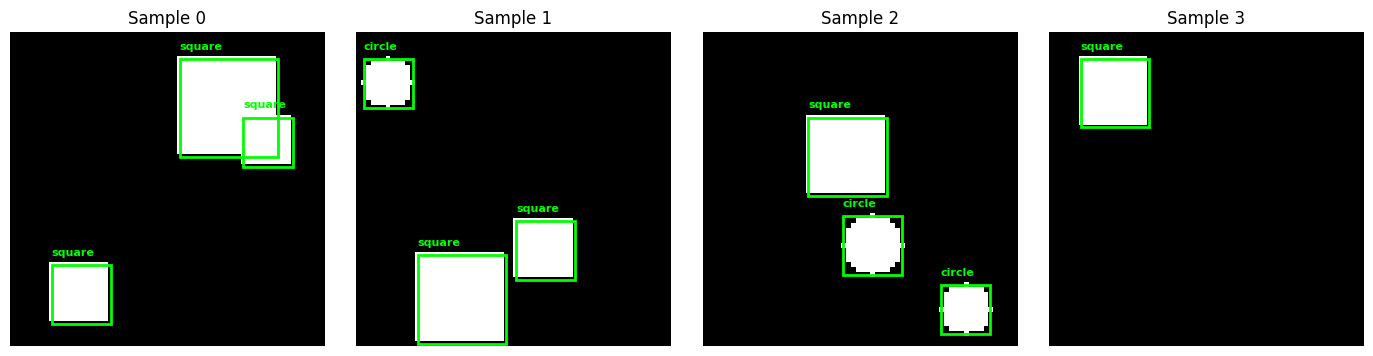

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
class_names = ['square', 'circle']
for i in range(4):
    sample = train_dataset[i]
    img = sample['image'][0].numpy()
    axes[i].imshow(img, cmap='gray')
    for j, (box, label) in enumerate(zip(sample['boxes'], sample['labels'])):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(x1, y1-2, class_names[label.item()], color='lime', fontsize=8, fontweight='bold')
    axes[i].set_title(f'Sample {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 3. CNN Backbone

A small 3-layer CNN that produces a shared feature map. Input: (B, 1, 64, 64) → Output: (B, 128, 8, 8). This replaces the VGG-16 backbone from the paper for feasibility on toy data.

In [4]:
class Backbone(nn.Module):
    """Small CNN backbone: 64x64 input → 8x8 feature map with 128 channels."""
    def __init__(self, in_channels=1, out_channels=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 → 32
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 → 16
            nn.Conv2d(64, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 → 8
        )
    def forward(self, x):
        return self.features(x)

backbone = Backbone().to(device)
dummy = torch.randn(2, 1, 64, 64).to(device)
feat = backbone(dummy)
print(f'Backbone output shape: {feat.shape}')  # (2, 128, 8, 8)
print(f'Backbone params: {sum(p.numel() for p in backbone.parameters()):,}')

Backbone output shape: torch.Size([2, 128, 8, 8])
Backbone params: 92,672


## 4. Anchor Generation

We generate anchor boxes at each feature-map location (8×8 = 64 positions). At each position, we place **9 anchors**: 3 scales × 3 aspect ratios. Total: 576 anchors. This follows the paper's design exactly, just on a smaller feature map.

In [5]:
def generate_anchors(img_size=64, feat_size=8, scales=[8, 16, 24], ratios=[0.5, 1.0, 2.0]):
    """Generate anchor boxes for all feature-map locations.
    Returns anchors in (x1, y1, x2, y2) format in image coordinates.
    Shape: (feat_size * feat_size * num_anchors_per_loc, 4)
    """
    stride = img_size // feat_size  # 8
    anchors = []
    for fy in range(feat_size):
        for fx in range(feat_size):
            cx = fx * stride + stride // 2
            cy = fy * stride + stride // 2
            for scale in scales:
                for ratio in ratios:
                    w = scale * np.sqrt(ratio)
                    h = scale / np.sqrt(ratio)
                    x1 = cx - w / 2
                    y1 = cy - h / 2
                    x2 = cx + w / 2
                    y2 = cy + h / 2
                    anchors.append([x1, y1, x2, y2])
    return torch.tensor(anchors, dtype=torch.float32)

anchors = generate_anchors()
print(f'Total anchors: {anchors.shape[0]}')
print(f'Anchor shape: {anchors.shape}')
print(f'Sample anchors (first 3):\n{anchors[:3]}')

Total anchors: 576
Anchor shape: torch.Size([576, 4])
Sample anchors (first 3):
tensor([[ 1.1716, -1.6569,  6.8284,  9.6569],
        [ 0.0000,  0.0000,  8.0000,  8.0000],
        [-1.6569,  1.1716,  9.6569,  6.8284]])


## 5. Visualize Anchors

Let's visualize the 9 anchor shapes at one feature-map location.

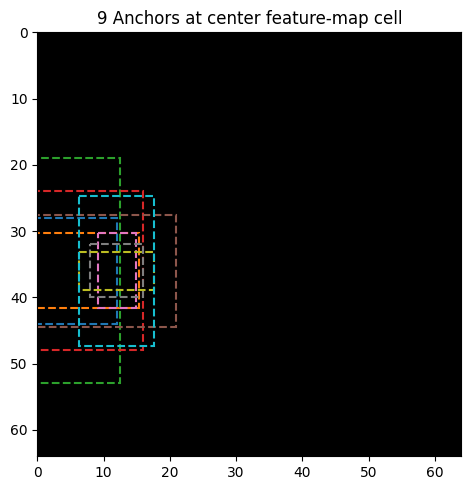

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(np.zeros((64, 64)), cmap='gray', extent=[0, 64, 64, 0])
# Show anchors at center location (4, 4) -> pixel (36, 36)
stride = 8
center_x = 4 * stride + stride // 2
center_y = 4 * stride + stride // 2
colors = plt.cm.tab10(np.linspace(0, 1, 9))
for i in range(9):
    x1, y1, x2, y2 = anchors[4 * 64 + 4 * 9 + i].tolist()
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1.5, 
                              edgecolor=colors[i], facecolor='none', linestyle='--')
    ax.add_patch(rect)
ax.set_title('9 Anchors at center feature-map cell')
ax.set_xlim(0, 64)
ax.set_ylim(64, 0)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 6. IoU and Box Utilities

IoU (Intersection over Union) is used to match anchors to ground-truth boxes. Box encoding/decoding follows the Faster R-CNN parameterization: `dx = (x - xa) / wa`, `dy = (y - ya) / ha`, `dw = log(w / wa)`, `dh = log(h / ha)`.

In [7]:
def compute_iou(boxes1, boxes2):
    """Compute pairwise IoU between two sets of boxes.
    boxes1: (N, 4), boxes2: (M, 4) → returns (N, M)
    """
    N, M = boxes1.shape[0], boxes2.shape[0]
    # Expand for broadcasting
    b1 = boxes1.unsqueeze(1)  # (N, 1, 4)
    b2 = boxes2.unsqueeze(0)  # (1, M, 4)
    # Intersection
    inter_x1 = torch.max(b1[..., 0], b2[..., 0])  # (N, M)
    inter_y1 = torch.max(b1[..., 1], b2[..., 1])
    inter_x2 = torch.min(b1[..., 2], b2[..., 2])
    inter_y2 = torch.min(b1[..., 3], b2[..., 3])
    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_w * inter_h
    # Union
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])  # (N,)
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])  # (M,)
    union = area1.unsqueeze(1) + area2.unsqueeze(0) - inter_area  # (N, M)
    iou = inter_area / union.clamp(min=1e-6)
    return iou

def encode_boxes(gt_boxes, anchor_boxes):
    """Encode GT boxes relative to anchors using Faster R-CNN parameterization.
    gt_boxes: (N, 4), anchor_boxes: (N, 4) → deltas (N, 4)
    """
    ga_w = anchor_boxes[:, 2] - anchor_boxes[:, 0]
    ga_h = anchor_boxes[:, 3] - anchor_boxes[:, 1]
    ga_cx = (anchor_boxes[:, 2] + anchor_boxes[:, 0]) / 2
    ga_cy = (anchor_boxes[:, 3] + anchor_boxes[:, 1]) / 2
    gt_w = gt_boxes[:, 2] - gt_boxes[:, 0]
    gt_h = gt_boxes[:, 3] - gt_boxes[:, 1]
    gt_cx = (gt_boxes[:, 2] + gt_boxes[:, 0]) / 2
    gt_cy = (gt_boxes[:, 3] + gt_boxes[:, 1]) / 2
    dx = (gt_cx - ga_cx) / ga_w
    dy = (gt_cy - ga_cy) / ga_h
    dw = torch.log(gt_w / ga_w.clamp(min=1e-6))
    dh = torch.log(gt_h / ga_h.clamp(min=1e-6))
    return torch.stack([dx, dy, dw, dh], dim=1)

def decode_boxes(deltas, anchor_boxes):
    """Decode predicted deltas back to image-space boxes.
    deltas: (N, 4), anchor_boxes: (N, 4) → boxes (N, 4)
    """
    ga_w = anchor_boxes[:, 2] - anchor_boxes[:, 0]
    ga_h = anchor_boxes[:, 3] - anchor_boxes[:, 1]
    ga_cx = (anchor_boxes[:, 2] + anchor_boxes[:, 0]) / 2
    ga_cy = (anchor_boxes[:, 3] + anchor_boxes[:, 1]) / 2
    cx = deltas[:, 0] * ga_w + ga_cx
    cy = deltas[:, 1] * ga_h + ga_cy
    w = torch.exp(deltas[:, 2]) * ga_w
    h = torch.exp(deltas[:, 3]) * ga_h
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return torch.stack([x1, y1, x2, y2], dim=1)

def clamp_boxes(boxes, img_size):
    """Clamp boxes to image boundaries (non-in-place)."""
    return torch.clamp(boxes, 0, img_size - 1)

# Test IoU
test_boxes1 = torch.tensor([[0, 0, 10, 10], [5, 5, 15, 15]], dtype=torch.float32)
test_boxes2 = torch.tensor([[0, 0, 10, 10]], dtype=torch.float32)
iou_test = compute_iou(test_boxes1, test_boxes2)
print(f'IoU test: {iou_test.squeeze()}')  # Should be [1.0, 0.17]

IoU test: tensor([1.0000, 0.1429])


## 7. Anchor Labeling (Target Assignment)

We match anchors to ground-truth boxes using IoU thresholds:
- IoU ≥ 0.7 → positive (object)
- IoU < 0.3 → negative (background)
- Best-IoU anchor per GT box is forced positive

During training, we sample 32 positive + 32 negative anchors for the RPN loss.

In [8]:
def assign_targets_to_anchors(anchors, gt_boxes, pos_iou_thresh=0.7, neg_iou_thresh=0.3):
    """Assign labels to anchors based on IoU with GT boxes.
    Returns: labels (N,), matched_gt_idx (N,) where -1 means no match.
    Label: 1=positive, 0=negative, -1=ignore
    """
    if gt_boxes.shape[0] == 0:
        labels = torch.full((anchors.shape[0],), -1, dtype=torch.long, device=anchors.device)
        matched_gt = torch.full((anchors.shape[0],), -1, dtype=torch.long, device=anchors.device)
        return labels, matched_gt
    iou = compute_iou(anchors, gt_boxes)  # (N_anchors, N_gt)
    best_iou_per_anchor, best_gt_per_anchor = iou.max(dim=1)
    labels = torch.full((anchors.shape[0],), -1, dtype=torch.long, device=anchors.device)
    labels[best_iou_per_anchor >= pos_iou_thresh] = 1
    labels[best_iou_per_anchor < neg_iou_thresh] = 0
    # Force best anchor for each GT box to be positive
    best_anchor_per_gt = iou.argmax(dim=0)  # (N_gt,)
    labels[best_anchor_per_gt] = 1
    matched_gt = torch.full((anchors.shape[0],), -1, dtype=torch.long, device=anchors.device)
    pos_mask = labels == 1
    matched_gt[pos_mask] = best_gt_per_anchor[pos_mask]
    return labels, matched_gt

def sample_anchors_for_training(labels, num_pos=32, num_neg=32):
    """Sample balanced positive/negative anchors for RPN training."""
    pos_idx = (labels == 1).nonzero(as_tuple=True)[0]
    neg_idx = (labels == 0).nonzero(as_tuple=True)[0]
    if len(pos_idx) > num_pos:
        perm = torch.randperm(len(pos_idx))[:num_pos]
        pos_idx = pos_idx[perm]
    if len(neg_idx) > num_neg:
        perm = torch.randperm(len(neg_idx))[:num_neg]
        neg_idx = neg_idx[perm]
    sampled_idx = torch.cat([pos_idx, neg_idx])
    sampled_labels = labels[sampled_idx]
    return sampled_idx, sampled_labels

# Test
test_gt = torch.tensor([[10, 10, 25, 25]], dtype=torch.float32)
test_labels, test_matched = assign_targets_to_anchors(anchors, test_gt)
print(f'Positive anchors: {(test_labels == 1).sum().item()}')
print(f'Negative anchors: {(test_labels == 0).sum().item()}')
print(f'Ignored anchors: {(test_labels == -1).sum().item()}')

Positive anchors: 1
Negative anchors: 557
Ignored anchors: 18


## 8. Non-Maximum Suppression (NMS)

NMS removes overlapping proposals, keeping only the highest-scoring box in each cluster. We use torchvision's `nms` implementation.

In [9]:
def apply_nms(boxes, scores, iou_threshold=0.7, max_proposals=50):
    """Apply NMS and return top-k proposal indices."""
    if boxes.shape[0] == 0:
        return torch.tensor([], dtype=torch.long)
    keep = torchvision.ops.nms(boxes, scores, iou_threshold)
    if len(keep) > max_proposals:
        keep = keep[:max_proposals]
    return keep

print('NMS utility defined (using torchvision.ops.nms)')

NMS utility defined (using torchvision.ops.nms)


## 9. Region Proposal Network (RPN)

The RPN is a fully convolutional network that:
1. Applies a 3×3 conv on the shared feature map (512 intermediate channels)
2. Has two 1×1 conv heads: objectness (2*k channels) and box regression (4*k channels)
3. Produces proposals via decoding + NMS

This is the core innovation of Faster R-CNN.

In [10]:
class RPNHead(nn.Module):
    """Region Proposal Network head."""
    def __init__(self, in_channels=128, mid_channels=128, num_anchors=9):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, mid_channels, 3, padding=1)
        self.cls = nn.Conv2d(mid_channels, num_anchors * 2, 1)  # 2: fg/bg
        self.bbox = nn.Conv2d(mid_channels, num_anchors * 4, 1)  # 4: dx,dy,dw,dh
    
    def forward(self, features):
        x = F.relu(self.conv(features))
        cls_logits = self.cls(x)  # (B, 2*k, H, W)
        bbox_deltas = self.bbox(x)  # (B, 4*k, H, W)
        # Reshape: (B, H*W*k, 2) and (B, H*W*k, 4)
        B, _, H, W = cls_logits.shape
        cls_logits = cls_logits.permute(0, 2, 3, 1).reshape(B, -1, 2)
        bbox_deltas = bbox_deltas.permute(0, 2, 3, 1).reshape(B, -1, 4)
        return cls_logits, bbox_deltas

rpn = RPNHead(in_channels=128, num_anchors=NUM_ANCHORS_PER_LOC).to(device)
test_feat = torch.randn(2, 128, 8, 8).to(device)
test_cls, test_bbox = rpn(test_feat)
print(f'RPN cls_logits: {test_cls.shape}')  # (2, 576, 2)
print(f'RPN bbox_deltas: {test_bbox.shape}')  # (2, 576, 4)
print(f'RPN params: {sum(p.numel() for p in rpn.parameters()):,}')

RPN cls_logits: torch.Size([2, 576, 2])
RPN bbox_deltas: torch.Size([2, 576, 4])
RPN params: 154,550


## 10. RPN Loss

The RPN loss combines:
- **Classification loss**: cross-entropy on objectness (foreground vs background)
- **Regression loss**: smooth L1 on box deltas for positive anchors only

In [11]:
def smooth_l1_loss(pred, target, beta=1.0):
    """Smooth L1 loss as in Faster R-CNN."""
    diff = pred - target
    abs_diff = diff.abs()
    loss = torch.where(abs_diff < beta, 0.5 * diff**2 / beta, abs_diff - 0.5 * beta)
    return loss.mean()

def compute_rpn_loss(cls_logits, bbox_deltas, anchors, gt_boxes,
                     num_pos=32, num_neg=32):
    """Compute RPN classification + regression loss for one image."""
    labels, matched_gt_idx = assign_targets_to_anchors(anchors, gt_boxes)
    sampled_idx, sampled_labels = sample_anchors_for_training(labels, num_pos, num_neg)
    
    if len(sampled_idx) == 0:
        cls_loss = cls_logits.new_zeros(1)
        reg_loss = bbox_deltas.new_zeros(1)
        return cls_loss, reg_loss
    
    # Classification loss
    sampled_cls_logits = cls_logits[sampled_idx]  # (N_sampled, 2)
    sampled_labels_bin = sampled_labels.clamp(min=0)  # 0 or 1
    cls_loss = F.cross_entropy(sampled_cls_logits, sampled_labels_bin)
    
    # Regression loss (only on positive anchors)
    pos_mask = sampled_labels == 1
    if pos_mask.sum() > 0:
        pos_idx = sampled_idx[pos_mask]
        pos_matched_gt = matched_gt_idx[pos_idx]
        pos_anchors = anchors[pos_idx]
        pos_gt_boxes = gt_boxes[pos_matched_gt]
        target_deltas = encode_boxes(pos_gt_boxes, pos_anchors)
        pred_deltas = bbox_deltas[pos_idx]
        reg_loss = smooth_l1_loss(pred_deltas, target_deltas)
    else:
        reg_loss = bbox_deltas.new_zeros(1)
    
    return cls_loss, reg_loss

print('RPN loss function defined')

RPN loss function defined


## 11. Proposal Generation

Given RPN outputs, we decode predicted boxes, clamp to image boundaries, score them by objectness, and apply NMS to get the top proposals.

In [12]:
def generate_proposals(rpn_cls_logits, rpn_bbox_deltas, anchors,
                        img_size=64, pre_nms_top=200, post_nms_top=50):
    """Generate proposals from RPN outputs for one image."""
    # Get objectness scores (foreground probability)
    scores = F.softmax(rpn_cls_logits, dim=1)[:, 1]  # (N_anchors,)
    # Decode boxes
    pred_boxes = decode_boxes(rpn_bbox_deltas, anchors)
    pred_boxes = clamp_boxes(pred_boxes.clone(), img_size)
    # Sort by score, take top pre_nms_top
    if scores.shape[0] > pre_nms_top:
        order = scores.argsort(descending=True)[:pre_nms_top]
        pred_boxes = pred_boxes[order]
        scores = scores[order]
    # NMS
    keep = apply_nms(pred_boxes, scores, iou_threshold=0.7, max_proposals=post_nms_top)
    return pred_boxes[keep], scores[keep]

print('Proposal generation function defined')

Proposal generation function defined


## 12. RoI Pooling

RoI Pooling extracts fixed-size (5×5) features from the shared feature map for each proposal. We map proposal boxes from image coordinates to feature-map coordinates and use adaptive max pooling.

In [13]:
def roi_pool(features, proposals, output_size=5):
    """RoI Pooling: extract fixed-size features for each proposal.
    features: (B, C, H, W) shared feature map
    proposals: (N, 4) boxes in image coordinates
    Returns: (N, C, output_size, output_size)
    """
    B, C, H, W = features.shape
    img_size = H * 8  # feature map is 8x downsampled (64→8)
    scale = H / img_size  # 1/8
    # Scale proposals to feature-map coordinates
    scaled_boxes = proposals.clone()
    scaled_boxes[:, 0] *= scale
    scaled_boxes[:, 1] *= scale
    scaled_boxes[:, 2] *= scale
    scaled_boxes[:, 3] *= scale
    
    pooled = []
    for i in range(scaled_boxes.shape[0]):
        x1, y1, x2, y2 = scaled_boxes[i].tolist()
        x1, y1 = int(max(0, x1)), int(max(0, y1))
        x2, y2 = int(min(W, x2)), int(min(H, y2))
        if x2 <= x1 or y2 <= y1:
            pooled.append(torch.zeros(C, output_size, output_size, device=features.device))
            continue
        region = features[0, :, y1:y2, x1:x2]  # (C, h, w)
        if region.shape[1] == 0 or region.shape[2] == 0:
            pooled.append(torch.zeros(C, output_size, output_size, device=features.device))
            continue
        # Adaptive max pool to output_size x output_size
        pooled_region = F.adaptive_max_pool2d(region.unsqueeze(0), (output_size, output_size))
        pooled.append(pooled_region.squeeze(0))
    if len(pooled) > 0:
        return torch.stack(pooled)  # (N, C, output_size, output_size)
    return torch.zeros(0, C, output_size, output_size, device=features.device)

print('RoI Pooling function defined')
# Test
test_proposals = torch.tensor([[5, 5, 30, 30], [10, 10, 50, 50]], dtype=torch.float32).to(device)
test_feat = torch.randn(1, 128, 8, 8).to(device)
test_roi = roi_pool(test_feat, test_proposals)
print(f'RoI pool output: {test_roi.shape}')  # (2, 128, 5, 5)

RoI Pooling function defined


RoI pool output: torch.Size([2, 128, 5, 5])


## 13. Detection Head (Fast R-CNN)

The detection head takes RoI-pooled features and:
1. Flattens → FC layers (→ 256 dim)
2. Classification: FC → (num_classes + 1) scores (includes background)
3. Box regression: FC → (num_classes + 1) × 4 box refinements

In [14]:
class DetectionHead(nn.Module):
    """Fast R-CNN style detection head over RoI-pooled features."""
    def __init__(self, in_channels=128, roi_size=5, num_classes=2, hidden=128):
        super().__init__()
        flat_dim = in_channels * roi_size * roi_size  # 128*5*5 = 3200
        self.fc1 = nn.Linear(flat_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.cls = nn.Linear(hidden, num_classes + 1)  # +1 for background
        self.bbox = nn.Linear(hidden, (num_classes + 1) * 4)  # class-specific regression
    
    def forward(self, roi_features):
        x = roi_features.flatten(1)  # (N, flat_dim)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        cls_logits = self.cls(x)  # (N, num_classes+1)
        bbox_pred = self.bbox(x)  # (N, (num_classes+1)*4)
        return cls_logits, bbox_pred

det_head = DetectionHead(in_channels=128, num_classes=NUM_CLASSES).to(device)
test_roi_feat = torch.randn(5, 128, 5, 5).to(device)
test_cls, test_bbox = det_head(test_roi_feat)
print(f'Det cls_logits: {test_cls.shape}')  # (5, 3)
print(f'Det bbox_pred: {test_bbox.shape}')  # (5, 12)
print(f'Detection head params: {sum(p.numel() for p in det_head.parameters()):,}')

Det cls_logits: torch.Size([5, 3])
Det bbox_pred: torch.Size([5, 12])
Detection head params: 428,175


## 14. Detection Loss

For each proposal, we match it to a GT box (by IoU) and compute:
- **Classification loss**: cross-entropy (including background class)
- **Regression loss**: smooth L1 on class-specific box refinement

In [15]:
def compute_detection_loss(cls_logits, bbox_pred, proposals, gt_boxes, gt_labels,
                            pos_iou_thresh=0.5, num_classes=2):
    """Compute detection head loss for one image's proposals."""
    if gt_boxes.shape[0] == 0 or proposals.shape[0] == 0:
        cls_loss = cls_logits.new_zeros(1)
        reg_loss = bbox_pred.new_zeros(1)
        return cls_loss, reg_loss
    
    # Match proposals to GT boxes
    iou = compute_iou(proposals, gt_boxes)  # (N_prop, N_gt)
    max_iou, matched_gt = iou.max(dim=1)
    
    # Assign labels: matched = GT class, unmatched = background (class index = num_classes)
    prop_labels = torch.full((proposals.shape[0],), num_classes, dtype=torch.long, device=proposals.device)
    pos_mask = max_iou >= pos_iou_thresh
    prop_labels[pos_mask] = gt_labels[matched_gt[pos_mask]]
    
    # Classification loss
    cls_loss = F.cross_entropy(cls_logits, prop_labels)
    
    # Regression loss (only on positive proposals)
    if pos_mask.sum() > 0:
        pos_idx = pos_mask.nonzero(as_tuple=True)[0]
        pos_labels = prop_labels[pos_idx]
        pos_gt_boxes = gt_boxes[matched_gt[pos_idx]]
        pos_proposals = proposals[pos_idx]
        target_deltas = encode_boxes(pos_gt_boxes, pos_proposals)
        
        # Extract predicted deltas for the correct class
        pred_bbox = bbox_pred[pos_idx]  # (N_pos, (num_classes+1)*4)
        pred_bbox = pred_bbox.view(-1, num_classes + 1, 4)  # (N_pos, num_classes+1, 4)
        pred_deltas = pred_bbox[torch.arange(len(pos_idx), device=pos_idx.device), pos_labels]  # (N_pos, 4)
        reg_loss = smooth_l1_loss(pred_deltas, target_deltas)
    else:
        reg_loss = bbox_pred.new_zeros(1)
    
    return cls_loss, reg_loss

print('Detection loss function defined')

Detection loss function defined


## 15. Full Faster R-CNN Model

Combining all components: Backbone → RPN → Proposals → RoI Pool → Detection Head.
The total loss is: `L = L_rpn_cls + L_rpn_reg + L_det_cls + L_det_reg`.

In [16]:
class FasterRCNN(nn.Module):
    """Simplified Faster R-CNN: Backbone + RPN + RoI Pool + Detection Head."""
    def __init__(self, num_classes=2, num_anchors=9):
        super().__init__()
        self.backbone = Backbone(in_channels=1, out_channels=128)
        self.rpn = RPNHead(in_channels=128, num_anchors=num_anchors)
        self.det_head = DetectionHead(in_channels=128, num_classes=num_classes)
    
    def forward(self, images, anchors, gt_boxes_list=None, gt_labels_list=None,
                num_proposals=30):
        """
        Forward pass. Returns dict with losses (if GT provided) and predictions.
        """
        B = images.shape[0]
        features = self.backbone(images)  # (B, 128, 8, 8)
        rpn_cls, rpn_bbox = self.rpn(features)  # (B, N_anchors, 2), (B, N_anchors, 4)
        
        total_rpn_cls_loss = 0.
        total_rpn_reg_loss = 0.
        total_det_cls_loss = 0.
        total_det_reg_loss = 0.
        all_proposals = []
        
        for b in range(B):
            # Generate proposals
            proposals, scores = generate_proposals(
                rpn_cls[b], rpn_bbox[b], anchors,
                img_size=IMAGE_SIZE, post_nms_top=num_proposals
            )
            all_proposals.append(proposals)
            
            if gt_boxes_list is not None:
                gt_boxes = gt_boxes_list[b]
                gt_labels = gt_labels_list[b]
                
                # RPN loss
                rpn_cls_loss, rpn_reg_loss = compute_rpn_loss(
                    rpn_cls[b], rpn_bbox[b], anchors, gt_boxes
                )
                total_rpn_cls_loss = total_rpn_cls_loss + rpn_cls_loss
                total_rpn_reg_loss = total_rpn_reg_loss + rpn_reg_loss
                
                # Detection loss
                if proposals.shape[0] > 0:
                    roi_feat = roi_pool(features[b:b+1], proposals)
                    det_cls, det_bbox = self.det_head(roi_feat)
                    det_cls_loss, det_reg_loss = compute_detection_loss(
                        det_cls, det_bbox, proposals, gt_boxes, gt_labels,
                        num_classes=NUM_CLASSES
                    )
                    total_det_cls_loss = total_det_cls_loss + det_cls_loss
                    total_det_reg_loss = total_det_reg_loss + det_reg_loss
        
        losses = {
            'rpn_cls': total_rpn_cls_loss / max(B, 1),
            'rpn_reg': total_rpn_reg_loss / max(B, 1),
            'det_cls': total_det_cls_loss / max(B, 1),
            'det_reg': total_det_reg_loss / max(B, 1),
        }
        losses['total'] = (losses['rpn_cls'] + losses['rpn_reg'] + 
                           losses['det_cls'] + losses['det_reg'])
        
        return losses, all_proposals
    
    def predict(self, images, anchors, num_proposals=30):
        """Inference: return predicted boxes, labels, scores per image."""
        B = images.shape[0]
        features = self.backbone(images)
        rpn_cls, rpn_bbox = self.rpn(features)
        results = []
        for b in range(B):
            proposals, scores = generate_proposals(
                rpn_cls[b], rpn_bbox[b], anchors,
                img_size=IMAGE_SIZE, post_nms_top=num_proposals
            )
            if proposals.shape[0] == 0:
                results.append({'boxes': torch.zeros(0, 4), 'labels': torch.zeros(0, dtype=torch.long), 'scores': torch.zeros(0)})
                continue
            roi_feat = roi_pool(features[b:b+1], proposals)
            det_cls, det_bbox = self.det_head(roi_feat)
            det_scores = F.softmax(det_cls, dim=1)
            det_labels = det_scores.argmax(dim=1)
            det_scores_val = det_scores.max(dim=1)[0]
            # Filter out background
            non_bg = det_labels < NUM_CLASSES
            results.append({
                'boxes': proposals[non_bg].cpu(),
                'labels': det_labels[non_bg].cpu(),
                'scores': det_scores_val[non_bg].cpu()
            })
        return results

model = FasterRCNN(num_classes=NUM_CLASSES, num_anchors=NUM_ANCHORS_PER_LOC).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total Faster R-CNN params: {total_params:,}')
print(f'  Backbone: {sum(p.numel() for p in model.backbone.parameters()):,}')
print(f'  RPN: {sum(p.numel() for p in model.rpn.parameters()):,}')
print(f'  Det head: {sum(p.numel() for p in model.det_head.parameters()):,}')

Total Faster R-CNN params: 675,397
  Backbone: 92,672
  RPN: 154,550
  Det head: 428,175


## 16. Training Loop

We train end-to-end with Adam optimizer for 5 epochs. The combined loss is: `L = L_rpn_cls + L_rpn_reg + L_det_cls + L_det_reg`.

Note: The paper uses alternating 4-step training; we use approximate joint training for simplicity.

In [17]:
anchors_device = anchors.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 3

loss_history = {'total': [], 'rpn_cls': [], 'rpn_reg': [], 'det_cls': [], 'det_reg': []}

print('Starting training...')
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    epoch_losses = {'total': 0., 'rpn_cls': 0., 'rpn_reg': 0., 'det_cls': 0., 'det_reg': 0.}
    num_batches = 0
    
    for images, gt_boxes_list, gt_labels_list in train_loader:
        images = images.to(device)
        gt_boxes_list = [b.to(device) for b in gt_boxes_list]
        gt_labels_list = [l.to(device) for l in gt_labels_list]
        
        optimizer.zero_grad()
        losses, _ = model(images, anchors_device, gt_boxes_list, gt_labels_list)
        loss = losses['total']
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        for k in epoch_losses:
            epoch_losses[k] = epoch_losses[k] + losses[k].item()
        num_batches += 1
    
    for k in epoch_losses:
        avg = epoch_losses[k] / num_batches
        loss_history[k].append(avg)
    
    elapsed = time.time() - start_time
    print(f'Epoch {epoch+1}/{num_epochs} | Total: {loss_history["total"][-1]:.4f} | '
          f'RPN cls: {loss_history["rpn_cls"][-1]:.4f} | RPN reg: {loss_history["rpn_reg"][-1]:.4f} | '
          f'Det cls: {loss_history["det_cls"][-1]:.4f} | Det reg: {loss_history["det_reg"][-1]:.4f} | '
          f'Time: {elapsed:.1f}s')

print(f'\nTraining complete in {time.time() - start_time:.1f}s')

Starting training...


Epoch 1/3 | Total: 1.1118 | RPN cls: 0.4334 | RPN reg: 0.0521 | Det cls: 0.5488 | Det reg: 0.0775 | Time: 3.8s


Epoch 2/3 | Total: 0.4487 | RPN cls: 0.1785 | RPN reg: 0.0217 | Det cls: 0.2291 | Det reg: 0.0194 | Time: 7.1s


Epoch 3/3 | Total: 0.4851 | RPN cls: 0.1278 | RPN reg: 0.0184 | Det cls: 0.3242 | Det reg: 0.0147 | Time: 10.1s

Training complete in 10.1s


## 17. Training Loss Curves

Let's visualize how each loss component decreases over training.

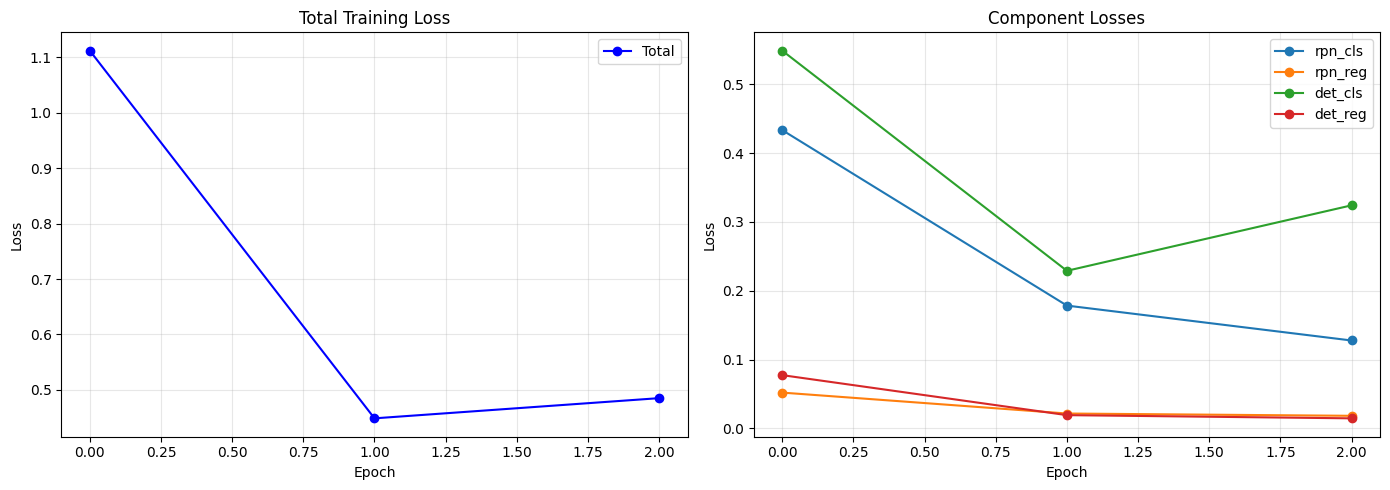

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total loss
axes[0].plot(loss_history['total'], 'b-o', label='Total')
axes[0].set_title('Total Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Component losses
for k in ['rpn_cls', 'rpn_reg', 'det_cls', 'det_reg']:
    axes[1].plot(loss_history[k], '-o', label=k)
axes[1].set_title('Component Losses')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 18. Visualize Predictions

Let's run the trained model on test images and draw predicted bounding boxes.

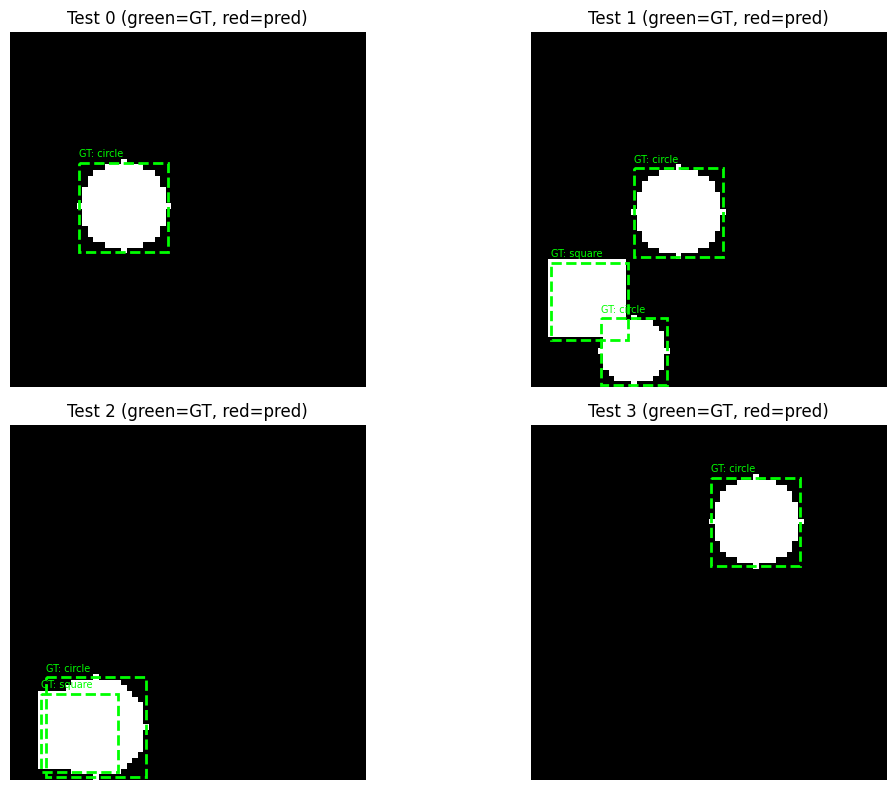

In [19]:
model.eval()
class_names = ['square', 'circle', 'background']

with torch.no_grad():
    test_images, test_boxes, test_labels = next(iter(test_loader))
    test_images = test_images.to(device)
    results = model.predict(test_images[:4], anchors_device)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i in range(4):
    ax = axes[i // 2, i % 2]
    img = test_images[i, 0].cpu().numpy()
    ax.imshow(img, cmap='gray')
    
    # Draw ground truth (green)
    for box, label in zip(test_boxes[i], test_labels[i]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                  edgecolor='lime', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(x1, y1-1, f'GT: {class_names[label.item()]}', color='lime', fontsize=7)
    
    # Draw predictions (red)
    res = results[i]
    for box, label, score in zip(res['boxes'], res['labels'], res['scores']):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                  edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y2+1, f'{class_names[label.item()]}: {score:.2f}',
                color='red', fontsize=7, fontweight='bold')
    
    ax.set_title(f'Test {i} (green=GT, red=pred)')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 19. Visualize RPN Proposals

Let's see what the RPN proposes before and after NMS.

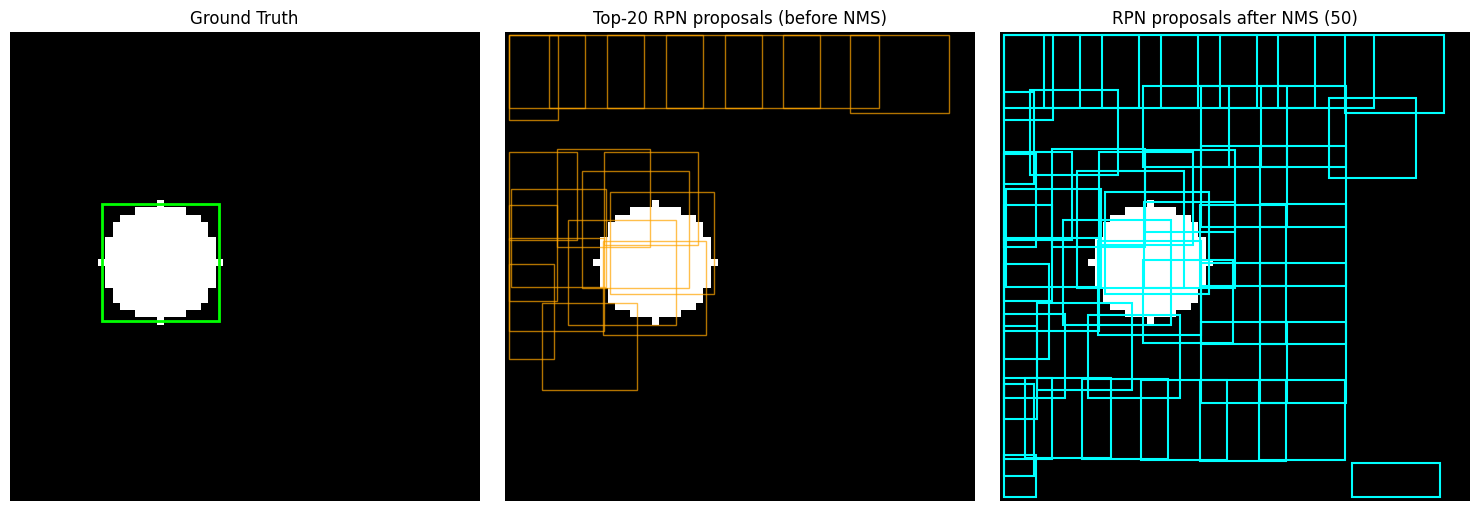

In [20]:
model.eval()
with torch.no_grad():
    sample_img = test_images[0:1]
    features = model.backbone(sample_img)
    rpn_cls, rpn_bbox = model.rpn(features)
    scores = F.softmax(rpn_cls[0], dim=1)[:, 1]
    all_boxes = decode_boxes(rpn_bbox[0], anchors_device)
    all_boxes = clamp_boxes(all_boxes.clone(), IMAGE_SIZE)
    
    # Top-20 before NMS
    top20_idx = scores.argsort(descending=True)[:20]
    top20_boxes = all_boxes[top20_idx].cpu()
    top20_scores = scores[top20_idx].cpu()
    
    # After NMS
    proposals, prop_scores = generate_proposals(rpn_cls[0], rpn_bbox[0], anchors_device)
    
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
img = sample_img[0, 0].cpu().numpy()

# Ground truth
axes[0].imshow(img, cmap='gray')
for box, label in zip(test_boxes[0], test_labels[0]):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                              edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# Top-20 before NMS
axes[1].imshow(img, cmap='gray')
for box, score in zip(top20_boxes, top20_scores):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1,
                              edgecolor='orange', facecolor='none', alpha=0.7)
    axes[1].add_patch(rect)
axes[1].set_title('Top-20 RPN proposals (before NMS)')
axes[1].axis('off')

# After NMS
axes[2].imshow(img, cmap='gray')
for box, score in zip(proposals.cpu(), prop_scores.cpu()):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1.5,
                              edgecolor='cyan', facecolor='none')
    axes[2].add_patch(rect)
axes[2].set_title(f'RPN proposals after NMS ({len(proposals)})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 20. Summary

This notebook implemented a **simplified Faster R-CNN** from scratch in PyTorch, including:

1. **Backbone CNN** — shared feature extraction (128 channels, 8×8 spatial)
2. **Anchor generation** — 9 anchors per location (3 scales × 3 ratios), 576 total
3. **Region Proposal Network (RPN)** — 3×3 conv + two 1×1 heads for objectness and box regression
4. **Anchor matching** — IoU-based assignment with 0.7/0.3 thresholds
5. **Non-Maximum Suppression** — reduces overlapping proposals to top-50
6. **RoI Pooling** — extracts 5×5 features per proposal from the shared feature map
7. **Detection Head** — FC classifier + class-specific box regressor (Fast R-CNN style)
8. **End-to-end training** — joint RPN + detection loss, Adam optimizer, 5 epochs

Key takeaways from the paper:
- The RPN makes region proposals **nearly cost-free** by sharing convolutional features with the detector
- **Anchors** enable multi-scale detection from a single feature map without image pyramids
- The unified network achieves **5 fps** with state-of-the-art accuracy — a 10× speedup over Selective Search
- Faster R-CNN became the foundation for Mask R-CNN, FPN, and the modern two-stage detection paradigm

**Simplifications vs. the full paper:** 3-layer backbone (vs VGG-16), 64×64 grayscale (vs 1000×600 RGB), 2 toy classes (vs 20 VOC classes), joint training (vs 4-step alternating), top-50 proposals (vs 300). The core algorithmic components — anchors, RPN, RoI pooling, detection head — faithfully follow the paper.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
